In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10

In [3]:
def plot_boundary(ax , model , X , y , title):
    x_min , x_max = X[ : , 0].min() - 0.6 , X[ : , 0].max() + 0.6
    y_min , y_max = X[ : , 1].min() - 0.6 , X[ : , 1].max() + 0.6
    xx , yy = np.meshgrid(np.linspace(x_min , x_max , 400) ,
                          np.linspace(y_min , y_max , 400))
    grid = np.c_[xx.ravel() , yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx , yy , Z , alpha = 0.18 , cmap = plt.cm.Pastel1)
    ax.contour(xx , yy , Z , levels = [0.5] , colors = "#6A1B9A" , linewidths = 2.2)
    ax.scatter(X[y == 0 , 0] ,  X[y == 0 , 1] , s = 42 , alpha = 0.85 ,
               color = "#4C78A8" , label = "Class 0")
    ax.scatter(X[y == 1 , 0] , X[y == 1 , 1] , s = 42 , alpha = 0.85 ,
               color = "#F58518" , label = "Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc = "upper right")

In [4]:
def plot_probability_surface(ax , model , X , y , title):
    x_min , x_max = X[ : , 0].min() - 0.6 , X[ : , 0].max() + 0.6
    y_min , y_max = X[ : , 1].min() - 0.6 , X[ : , 1].max() + 0.6
    xx , yy = np.meshgrid(np.linspace(x_min , x_max , 400) ,
                          np.linspace(y_min , y_max , 400))
    grid = np.c_[xx.ravel() , yy.ravel()]
    probs = model.predict_proba(grid)[ : , 1].reshape(xx.shape)
    ax.grid(False)
    contour = ax.contourf(xx , yy , probs , levels = 20 , alpha = 0.80 , cmap = "viridis")
    ax.contour(xx , yy , probs , levels = [0.5] , colors = "#D81B60" , linewidths = 2.4)
    ax.scatter(X[y == 0 , 0] , X[y == 0 , 1] , s = 36 , alpha = 0.75 ,
               color = "#4C78A8" , label = "Class 0")
    ax.scatter(X[y == 1 , 0] , X[y == 1 , 1] , s = 36 , alpha = 0.75 ,
               color = "#F58518" , label = "Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc = "upper right")
    return contour

In [5]:
def train_and_evaluate_week7(X , y):
    X_train , X_temp , y_train , y_temp = train_test_split(
        X , y , test_size = 0.40 , stratify = y , random_state = 42)
    X_val , X_test , y_val , y_test = train_test_split(
        X_temp , y_temp , test_size = 0.50 , stratify = y_temp , random_state = 42)
    simple_model = Pipeline([("scaler" , StandardScaler()) ,
     ("logreg" , LogisticRegression(max_iter = 2000))])
    flexible_model = Pipeline([
        ("poly" , PolynomialFeatures(degree = 3 , include_bias = False)) ,
        ("scaler" , StandardScaler()) ,
        ("logreg" , LogisticRegression(max_iter = 2000))])
    models = {"Simple": simple_model , "Flexible": flexible_model}
    results = {}
    for name , model in models.items():
        model.fit(X_train , y_train)
        results[name] = {"model": model ,
                         "train": accuracy_score(y_train , model.predict(X_train)) ,
                         "val": accuracy_score(y_val , model.predict(X_val)) ,
                         "test": accuracy_score(y_test, model.predict(X_test))}
    selected_name = max(results , key = lambda k: results[k]["val"])
    selected_test = results[selected_name]["test"]
    split_data = {"X_train": X_train , "y_train": y_train , "X_val": X_val ,
                  "y_val": y_val , "X_test": X_test , "y_test": y_test}
    return results , selected_name , selected_test , split_data

In [6]:
X , y = make_moons(n_samples = 300 , noise = 0.25 , random_state = 42)
results , selected_name , selected_test , split_data = train_and_evaluate_week7(X , y)
print(" " * 23 , "Accuracy Summary")
print("-" * 69)
for name in ["Simple" , "Flexible"]:
    r = results[name]
    print(f"{name:8s} -> " f"Train: {r['train']:.3f}, " f"Val: {r['val']:.3f}, "
          f"Test: {r['test']:.3f}")
print("\nSelected Model (by validation):")
print(selected_name)
print(f"\nFinal Test Accuracy: {selected_test:.3f}")
print("\n" , " " * 15 , "Week 7 Checklist")
print("-" * 46)
print("1. Use train / validation / test splits.")
print("2. Choose models using validation, not test.")
print("3. Compare simple vs flexible boundaries.")
print("4. Watch train vs validation gaps for overfitting.")
print("5. Use test only once at the end.")

                        Accuracy Summary
---------------------------------------------------------------------
Simple   -> Train: 0.878, Val: 0.883, Test: 0.850
Flexible -> Train: 0.900, Val: 0.900, Test: 0.833

Selected Model (by validation):
Flexible

Final Test Accuracy: 0.833

                 Week 7 Checklist
----------------------------------------------
1. Use train / validation / test splits.
2. Choose models using validation, not test.
3. Compare simple vs flexible boundaries.
4. Watch train vs validation gaps for overfitting.
5. Use test only once at the end.


Text(0.5, 1.0, 'Week 7 Toy Dataset')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

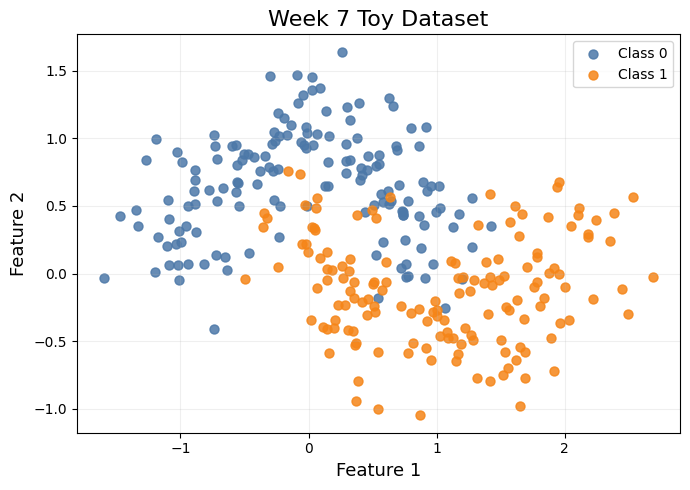

In [7]:
fig , ax = plt.subplots(figsize = (7 , 5))
ax.scatter(X[y == 0 , 0] , X[y == 0 , 1] , s = 42 , alpha = 0.85 ,
           color = "#4C78A8" , label = "Class 0")
ax.scatter(X[y == 1 , 0] , X[y == 1 , 1] , s = 42 , alpha = 0.85 ,
           color = "#F58518" , label = "Class 1")
ax.set_title("Week 7 Toy Dataset")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend(loc = "upper right")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Same Dataset, Different Roles: Train / Validation / Test')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

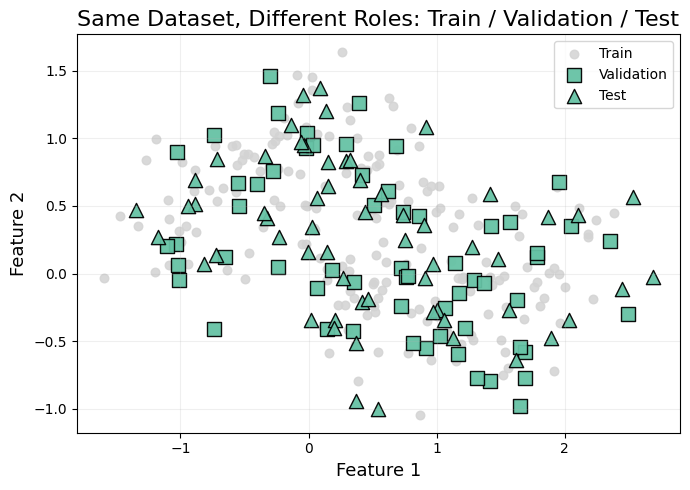

In [8]:
fig , ax = plt.subplots(figsize = (7 , 5))
ax.scatter(split_data["X_train"][ : , 0] , split_data["X_train"][ : , 1] ,
           c = "lightgray" , s = 38 , alpha = 0.85 , label = "Train")
ax.scatter(split_data["X_val"][ : , 0] , split_data["X_val"][ : , 1] ,
           c = "#66C2A5" , s = 90 , marker = "s" , alpha = 0.95 ,
           edgecolor = "black" , linewidth = 1.0 , label = "Validation")
ax.scatter(split_data["X_test"][ : , 0] , split_data["X_test"][ : , 1] ,
           c = "#66C2A5" , s = 105 , marker = "^" , alpha = 0.95 ,
           edgecolor = "black" , linewidth = 1.0 , label = "Test")
ax.set_title("Same Dataset, Different Roles: Train / Validation / Test")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend(loc = "upper right")
fig.tight_layout()
plt.show()

Text(0.5, 1.02, 'Week 7 Summary: Simple vs Flexible Models')

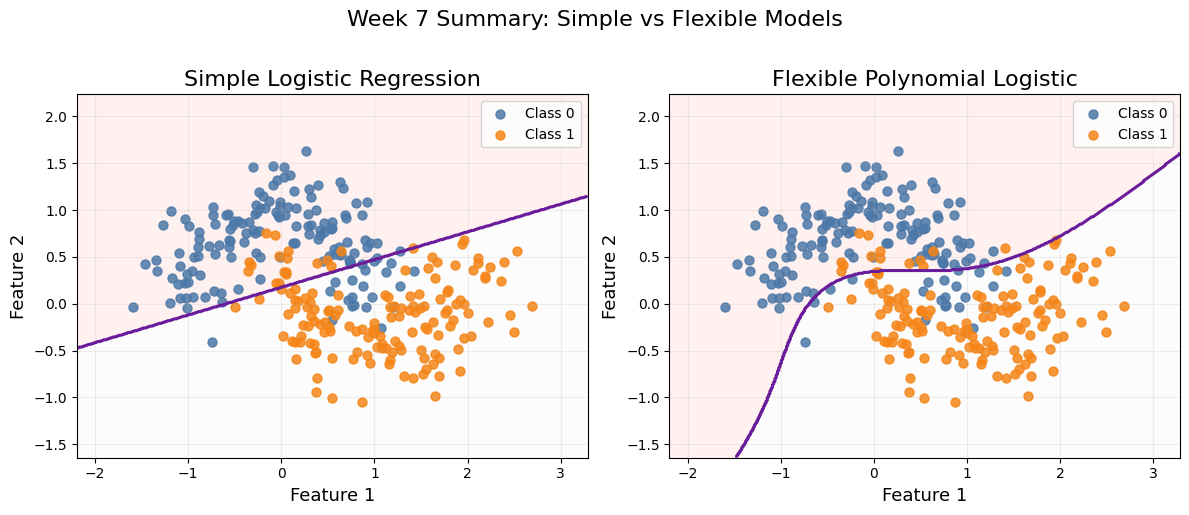

In [9]:
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 5))
plot_boundary(axes[0] , results["Simple"]["model"] , X , y , "Simple Logistic Regression")
plot_boundary(axes[1] , results["Flexible"]["model"] , X , y , "Flexible Polynomial Logistic")
fig.suptitle("Week 7 Summary: Simple vs Flexible Models" , y = 1.02 , fontsize = 16)
fig.tight_layout()
plt.show()

[Text(0, 0, 'Simple'), Text(1, 0, 'Flexible')]

(0.75, 1.0)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Model Comparison: Train vs Validation vs Test')

Text(-0.24, 0.8827777777777778, '0.878')

Text(0.76, 0.905, '0.900')

Text(0.0, 0.8883333333333333, '0.883')

Text(1.0, 0.905, '0.900')

Text(0.24, 0.855, '0.850')

Text(1.2400000000000002, 0.8383333333333334, '0.833')

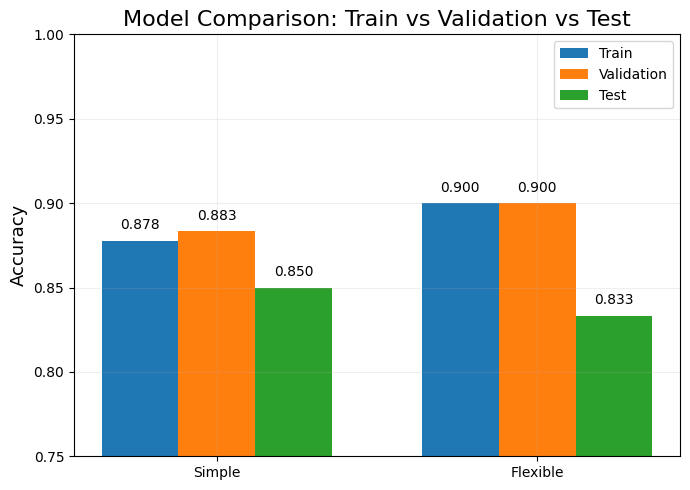

In [10]:
labels = ["Simple" , "Flexible"]
train_scores = [results["Simple"]["train"] , results["Flexible"]["train"]]
val_scores = [results["Simple"]["val"] , results["Flexible"]["val"]]
test_scores = [results["Simple"]["test"] , results["Flexible"]["test"]]
x = np.arange(len(labels))
width = 0.24
fig , ax = plt.subplots(figsize = (7 , 5))
bars1 = ax.bar(x - width , train_scores , width , label = "Train")
bars2 = ax.bar(x , val_scores , width , label = "Validation")
bars3 = ax.bar(x + width , test_scores , width , label = "Test")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.75 , 1.00)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison: Train vs Validation vs Test")
ax.legend(loc = "upper right")
for bars in [bars1 , bars2 , bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2 , h + 0.005 , f"{h:.3f}" ,
                ha = "center" , va = "bottom" , fontsize = 10)
fig.tight_layout()
plt.show()

(0.75, 1.0)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Selected Model Check: Flexible')

Text(0.0, 0.905, '0.900')

Text(1.0, 0.8383333333333334, '0.833')

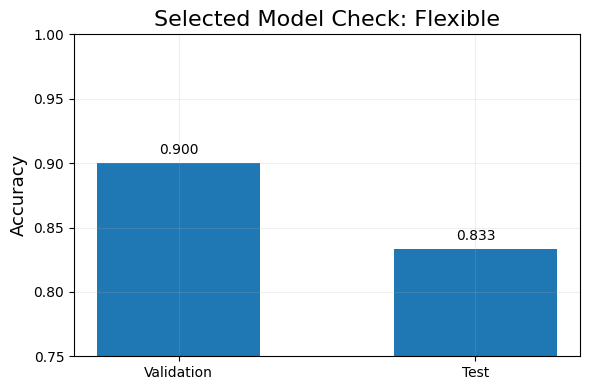

In [11]:
fig , ax = plt.subplots(figsize = (6 , 4))
summary_labels = ["Validation" , "Test"]
summary_scores = [results[selected_name]["val"] , results[selected_name]["test"]]
bars = ax.bar(summary_labels , summary_scores , width = 0.55)
ax.set_ylim(0.75 , 1.00)
ax.set_ylabel("Accuracy")
ax.set_title(f"Selected Model Check: {selected_name}")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2 , h + 0.005 , f"{h:.3f}" ,
            ha = "center" , va = "bottom" , fontsize = 10)
fig.tight_layout()
plt.show()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

Text(0.5, 1.0, 'Week 7 Score Summary')

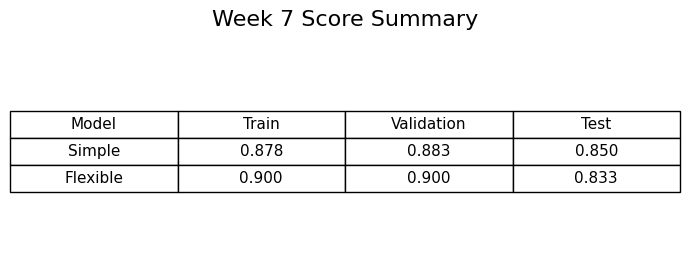

In [12]:
fig , ax = plt.subplots(figsize = (7 , 2.8))
ax.axis("off")
table_data = [
    ["Simple" , f"{results['Simple']['train']:.3f}" ,
     f"{results['Simple']['val']:.3f}" , f"{results['Simple']['test']:.3f}"] ,
      ["Flexible" , f"{results['Flexible']['train']:.3f}" ,
       f"{results['Flexible']['val']:.3f}" , f"{results['Flexible']['test']:.3f}"] , ]
table = ax.table(cellText = table_data ,
                 colLabels = ["Model" , "Train" , "Validation" , "Test"] ,
                 loc = "center" , cellLoc = "center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1 , 1.6)
ax.set_title("Week 7 Score Summary" , pad = 12)
fig.tight_layout()
plt.show()

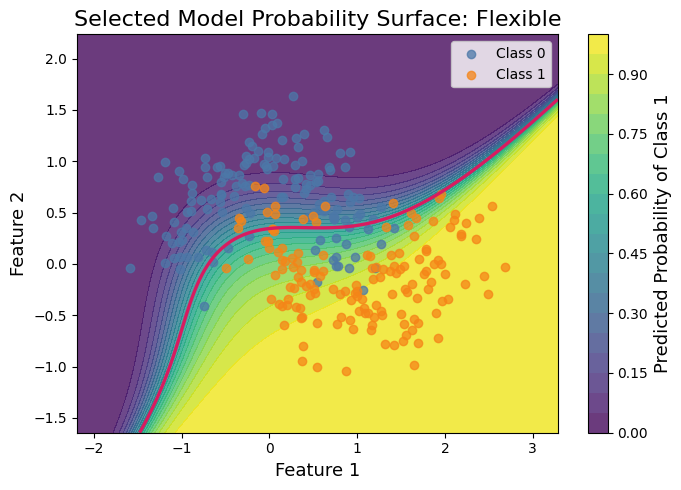

In [13]:
fig , ax = plt.subplots(figsize = (7 , 5))
contour = plot_probability_surface(ax , results[selected_name]["model"] , X , y ,
                                   f"Selected Model Probability Surface: {selected_name}")
cbar = fig.colorbar(contour)
cbar.set_label("Predicted Probability of Class 1")
fig.tight_layout()
plt.show()